In [1]:
import pandas as pd 
import numpy as np 

#ML
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.metrics import accuracy_score
from scipy import stats
import matplotlib.pyplot as plt
import os
import random
from sklearn.metrics import r2_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from scipy import stats
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
import networkx as nx

In [3]:
# --- Configuration: Define base directories ---
NETWORK_DIR = '../networks/unweighted'
RESULT_DIR = '../result_small_world/unweighted'


In [9]:
def load_graph(file_path):
    """
    Load a graph from a GraphML file and preprocess node labels.
    """
    G = nx.read_graphml(file_path)
    mapping = {node: int(float(node)) for node in G.nodes()}
    G = nx.relabel_nodes(G, mapping)
    return G

In [19]:
network_name = "email_eu_modified"
# network_name = "conf"
# network_name = "school"

graph_path = os.path.join(NETWORK_DIR, f'G_unweighted_{network_name}.graphml')
G = load_graph(graph_path)

Number of nodes: 986
Number of edges: 16687
Mean degree: 33.84787018255578
Median degree: 24.0

Degree percentiles:
  0th percentile: 1.0
 10th percentile: 2.0
 25th percentile: 7.0
 50th percentile: 24.0
 75th percentile: 46.0
 90th percentile: 79.5
 95th percentile: 107.75
 99th percentile: 171.29999999999995
100th percentile: 347.0


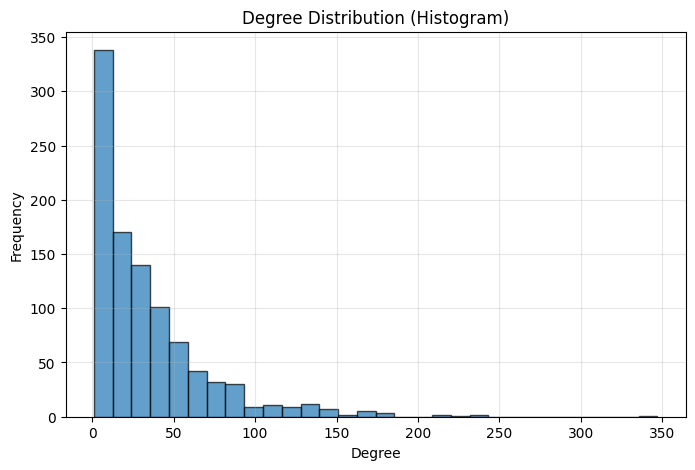

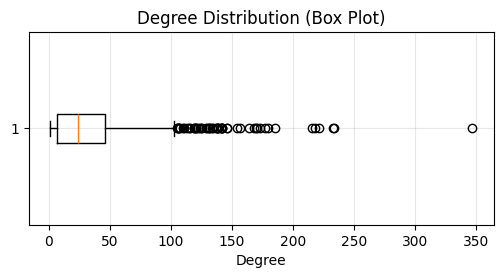

In [21]:
# Assuming your graph is named G
degrees = [d for _, d in G.degree()]

# Print basic stats and percentiles
print("Number of nodes:", len(G))
print("Number of edges:", len(G.edges()))
print("Mean degree:", np.mean(degrees))
print("Median degree:", np.median(degrees))

percentiles = np.percentile(degrees, [0, 10, 25, 50, 75, 90, 95, 99, 100])
print("\nDegree percentiles:")
for p, v in zip([0,10,25,50,75,90,95,99,100], percentiles):
    print(f"{p:>3}th percentile: {v}")

# Plot histogram
plt.figure(figsize=(8,5))
plt.hist(degrees, bins=30, edgecolor='black', alpha=0.7)
plt.title("Degree Distribution (Histogram)")
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.show()

# Plot boxplot
plt.figure(figsize=(6,2.5))
plt.boxplot(degrees, vert=False)
plt.title("Degree Distribution (Box Plot)")
plt.xlabel("Degree")
plt.grid(alpha=0.3)
plt.show()